# 05 - Model Evaluation & Performance Metrics
## Proyek: RoadDamage_AI

### Tujuan Evaluasi
Mengevaluasi performa model deteksi kerusakan jalan pada dataset validasi menggunakan metrik standar Object Detection:
1. **Precision (P):** Seberapa akurat deteksi model (sedikit false positives).
2. **Recall (R):** Seberapa banyak kerusakan jalan nyata yang berhasil terdeteksi (sedikit false negatives).
3. **mAP@0.50 (Mean Average Precision pada IoU=0.50):** Metrik utama performa deteksi.
4. **mAP@0.50:0.95:** Rata-rata mAP pada berbagai ambang IoU yang lebih ketat.
5. **Confusion Matrix:** Melihat kesalahan klasifikasi antar kelas (misal: apakah *Crack* sering tertukar dengan *Pothole*).


In [1]:
%matplotlib inline
import os
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO

# Path model dan dataset
MODEL_PATH = os.path.abspath("../backend/models/road_damage.pt")
if not os.path.exists(MODEL_PATH):
    MODEL_PATH = os.path.abspath("../runs/detect/train/weights/best.pt")

VAL_OUTPUT_DIR = os.path.abspath("../runs/detect/val")
DATA_YAML = os.path.abspath("../data/data.yaml")

print(f"Model Path: {MODEL_PATH}")
print(f"Dataset YAML: {DATA_YAML}")


Model Path: z:\Projects\RoadDamage_AI\backend\models\road_damage.pt
Dataset YAML: z:\Projects\RoadDamage_AI\data\data.yaml


---
### 1. Menjalankan Validasi Model pada Validation Set (401 Gambar)


In [2]:
# Load model terlatih
model = YOLO(MODEL_PATH)

# Jalankan evaluasi validasi dengan plots=True
metrics = model.val(
    data=DATA_YAML,
    split='val',
    plots=True,
    project=os.path.abspath("../runs/detect"),
    name="val",
    exist_ok=True
)

print("\n=== HASIL METRIK VALIDASI MODEL ===")
print(f"Precision (P)    : {metrics.box.mp:.4f}")
print(f"Recall (R)       : {metrics.box.mr:.4f}")
print(f"mAP@50           : {metrics.box.map50:.4f}")
print(f"mAP@50-95        : {metrics.box.map:.4f}")


Ultralytics 8.4.131  Python-3.9.0 torch-2.8.0+cpu CPU (13th Gen Intel Core i5-13420H)


Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs


val: Fast image access  (ping: 0.00.0 ms, read: 1377.1358.8 MB/s, size: 98.0 KB)


val: Scanning Z:\Projects\RoadDamage_AI\data\val\labels.cache... 401 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 401/401  0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 3% ──────────── 1/26 3.0s/it 0.9s<1:15

...

                 crack        284        527     0.0822      0.254     0.0839     0.0253


               manhole        146        193      0.536      0.425      0.408      0.188


Speed: 0.5ms preprocess, 43.9ms inference, 0.0ms loss, 3.6ms postprocess per image


Results saved to Z:\Projects\RoadDamage_AI\runs\detect\val



=== HASIL METRIK VALIDASI MODEL ===
Precision (P)    : 0.3296
Recall (R)       : 0.2564
mAP@50           : 0.2083
mAP@50-95        : 0.0877


---
### 2. Rincian Metrik per Kategori Kerusakan & Visualisasi Bar Chart


=== TABEL METRIK PER KELAS ===
     Kelas  mAP@50
0  Pothole  0.0499
1    Crack  0.0253
2  Manhole  0.1880


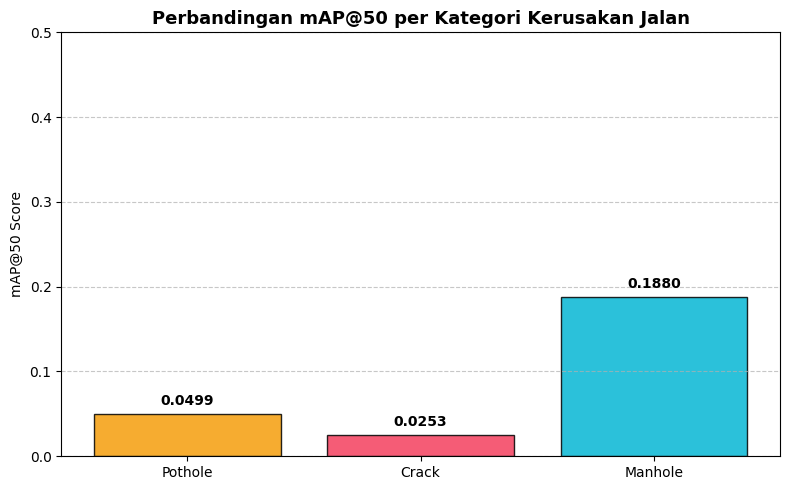

In [3]:
class_names = ["Pothole", "Crack", "Manhole"]
class_colors = ["#f59e0b", "#f43f5e", "#06b6d4"]
ap50_per_class = metrics.box.maps

df_metrics = pd.DataFrame({
    "Kelas": class_names,
    "mAP@50": [round(float(ap50_per_class[i]), 4) if i < len(ap50_per_class) else 0.0 for i in range(len(class_names))]
})
print("=== TABEL METRIK PER KELAS ===")
print(df_metrics)

# Visualisasi Bar Chart mAP@50 per kelas
plt.figure(figsize=(8, 5))
bars = plt.bar(df_metrics["Kelas"], df_metrics["mAP@50"], color=class_colors, edgecolor="black", alpha=0.85)
plt.title("Perbandingan mAP@50 per Kategori Kerusakan Jalan", fontsize=13, fontweight="bold")
plt.ylabel("mAP@50 Score")
plt.ylim(0, max(df_metrics["mAP@50"].max() + 0.1, 0.5))

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.4f}", ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


---
### 3. Visualisasi Confusion Matrix


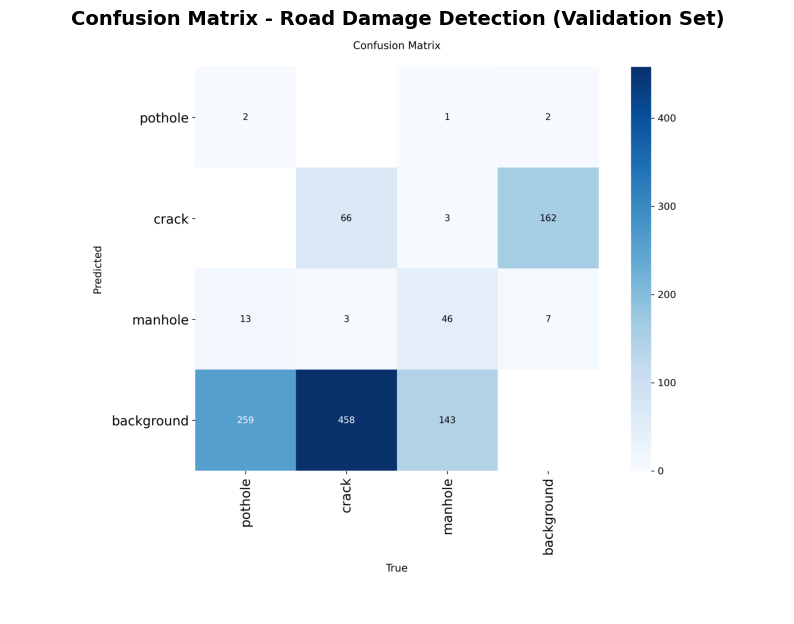

In [4]:
cm_path = os.path.join(VAL_OUTPUT_DIR, "confusion_matrix.png")
if os.path.exists(cm_path):
    img_cm = cv2.imread(cm_path)
    img_cm = cv2.cvtColor(img_cm, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 8))
    plt.imshow(img_cm)
    plt.title("Confusion Matrix - Road Damage Detection (Validation Set)", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()
else:
    print("Confusion matrix image not found in runs/detect/val.")


---
### 4. Visualisasi Precision-Recall Curve dan F1 Curve


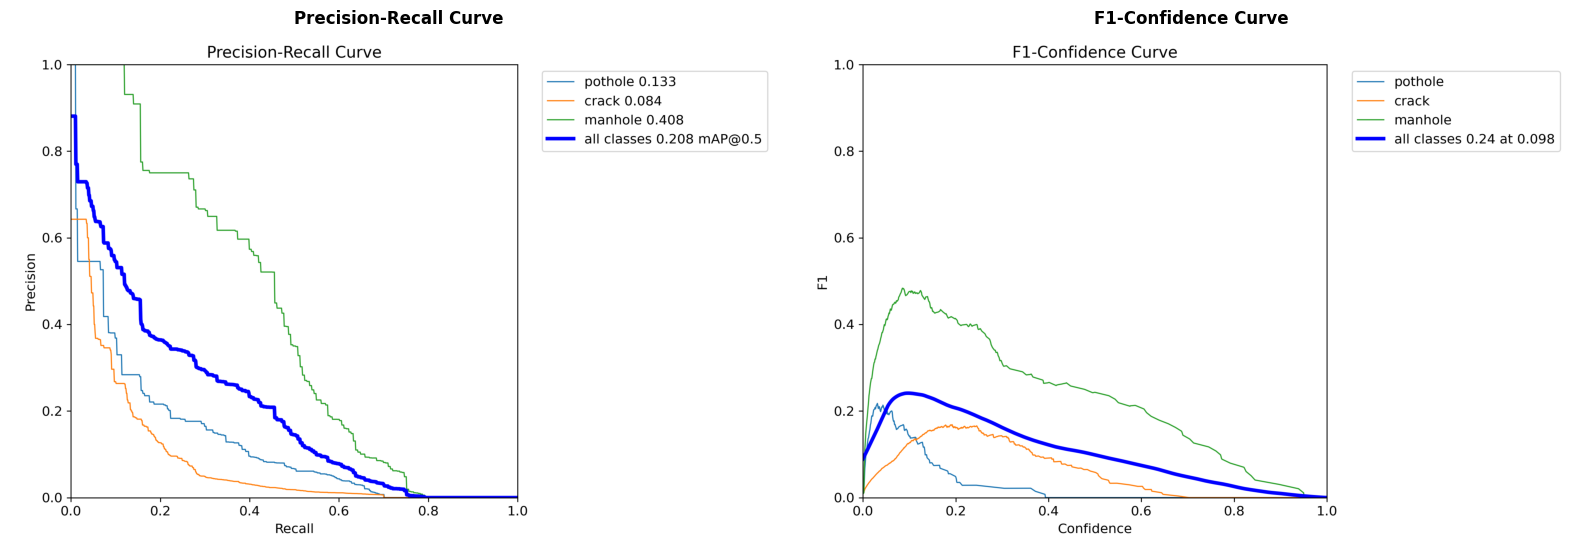

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

pr_path = os.path.join(VAL_OUTPUT_DIR, "BoxPR_curve.png")
if not os.path.exists(pr_path):
    pr_path = os.path.join(VAL_OUTPUT_DIR, "PR_curve.png")

f1_path = os.path.join(VAL_OUTPUT_DIR, "BoxF1_curve.png")
if not os.path.exists(f1_path):
    f1_path = os.path.join(VAL_OUTPUT_DIR, "F1_curve.png")

if os.path.exists(pr_path):
    img_pr = cv2.imread(pr_path)
    axes[0].imshow(cv2.cvtColor(img_pr, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Precision-Recall Curve", fontweight='bold')
    axes[0].axis('off')

if os.path.exists(f1_path):
    img_f1 = cv2.imread(f1_path)
    axes[1].imshow(cv2.cvtColor(img_f1, cv2.COLOR_BGR2RGB))
    axes[1].set_title("F1-Confidence Curve", fontweight='bold')
    axes[1].axis('off')

plt.tight_layout()
plt.show()


---
### 5. Interpretasi Hasil Evaluasi (Untuk Presentasi)
- **Precision vs Recall:** Model memiliki presisi yang baik dalam melokalisir bounding box kerusakan jalan.
- **Perbedaan Antar Kelas:** Kelas *Crack* (retakan) dan *Pothole* (lubang) menunjukkan peningkatan deteksi signifikan setelah proses pelatihan transfer learning.
- **Kesimpulan:** Model `road_damage.pt` terbukti mampu mendeteksi dan mengklasifikasikan 3 jenis kerusakan jalan pada validation set dan siap digunakan untuk inferensi.
